Task 1 – Create the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make output reproducible
np.random.seed(42)

# Dataset
hours = np.arange(1, 21)
scores = hours * 4.5 + np.random.randint(-3, 4, size=20)

data = pd.DataFrame({
    "Hours_Studied": hours,
    "Exam_Score": scores
})

print(data.head())
print("\nShape:", data.shape)

   Hours_Studied  Exam_Score
0              1         7.5
1              2         9.0
2              3        14.5
3              4        21.0
4              5        21.5

Shape: (20, 2)


In [2]:
X = data[["Hours_Studied"]].values
y = data[["Exam_Score"]].values

Task 2 – Initialize the Network Parameters

Architecture:

Input Layer = 1 neuron
Hidden Layer = 4 neurons
Output Layer = 1 neuron

In [3]:
np.random.seed(42)

# Input -> Hidden
W1 = np.random.randn(1, 4)
b1 = np.zeros((1, 4))

# Hidden -> Output
W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (1, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)


Task 3 – Implement ReLU

In [4]:
def relu(x):
    return np.maximum(0, x)

# Test ReLU
test = np.array([-3, -1, 0, 2, 5])

print("Input :", test)
print("Output:", relu(test))

Input : [-3 -1  0  2  5]
Output: [0 0 0 2 5]


Task 4 – Implement the Linear Activation

In [5]:
def linear(x):
    return x

Task 5 – Write the Forward Pass Function

In [6]:
def forward(X, W1, b1, W2, b2):
    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    Y_pred = linear(Z2)

    return Z1, A1, Z2, Y_pred

In [7]:
X_test = X[:4]

Z1, A1, Z2, predictions = forward(X_test, W1, b1, W2, b2)

print("Predicted Scores:")
print(predictions)

Predicted Scores:
[[2.07535675]
 [4.1507135 ]
 [6.22607025]
 [8.301427  ]]


Task 6 – Implement the Mean Squared Error (MSE) Loss

In [8]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [9]:
y_test = y[:4]

loss = mse_loss(y_test, predictions)

print("Loss:", loss)

Loss: 70.66350092465285


Task 7 – Implement Backpropagation

In [10]:
def backprop(X, y, Z1, A1, Y_pred, W2):
    m = X.shape[0]

    # Output layer gradients
    dZ2 = (2/m) * (Y_pred - y)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)      # ReLU derivative

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [11]:
dW1, db1, dW2, db2 = backprop(
    X_test,
    y_test,
    Z1,
    A1,
    predictions,
    W2
)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW1 shape: (1, 4)
db1 shape: (1, 4)
dW2 shape: (4, 1)
db2 shape: (1, 1)


Task 8 – Implement One Optimizer Step

In [12]:
def update_params(W1, b1, W2, b2,
                  dW1, db1, dW2, db2,
                  learning_rate):

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return W1, b1, W2, b2

In [13]:
learning_rate = 0.001

W1, b1, W2, b2 = update_params(
    W1, b1, W2, b2,
    dW1, db1, dW2, db2,
    learning_rate
)

print("Parameters updated successfully!")

Parameters updated successfully!


Task 9 – Split the Data into Batches

In [14]:
def create_batches(X, y, batch_size):
    batches = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        batches.append((X_batch, y_batch))

    return batches

In [15]:
batch_size = 4

batches = create_batches(X, y, batch_size)

print("Number of batches:", len(batches))

Number of batches: 5


Task 10 – Full Training Loop

In [16]:
learning_rate = 0.001
epochs = 100

loss_history = []

for epoch in range(epochs):

    batches = create_batches(X, y, batch_size)

    epoch_loss = 0

    for X_batch, y_batch in batches:

        # Forward pass
        Z1, A1, Z2, Y_pred = forward(X_batch, W1, b1, W2, b2)

        # Loss
        loss = mse_loss(y_batch, Y_pred)
        epoch_loss += loss

        # Backpropagation
        dW1, db1, dW2, db2 = backprop(
            X_batch,
            y_batch,
            Z1,
            A1,
            Y_pred,
            W2
        )

        # Update parameters
        W1, b1, W2, b2 = update_params(
            W1,
            b1,
            W2,
            b2,
            dW1,
            db1,
            dW2,
            db2,
            learning_rate
        )

    epoch_loss /= len(batches)
    loss_history.append(epoch_loss)

Task 11 – Print the Loss Every 10 Epochs

In [17]:
learning_rate = 0.001
epochs = 100

loss_history = []

for epoch in range(epochs):

    batches = create_batches(X, y, batch_size)

    epoch_loss = 0

    for X_batch, y_batch in batches:

        Z1, A1, Z2, Y_pred = forward(X_batch, W1, b1, W2, b2)

        loss = mse_loss(y_batch, Y_pred)
        epoch_loss += loss

        dW1, db1, dW2, db2 = backprop(
            X_batch,
            y_batch,
            Z1,
            A1,
            Y_pred,
            W2
        )

        W1, b1, W2, b2 = update_params(
            W1,
            b1,
            W2,
            b2,
            dW1,
            db1,
            dW2,
            db2,
            learning_rate
        )

    epoch_loss /= len(batches)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss = {epoch_loss:.4f}")

Epoch 1, Loss = 1249.2026
Epoch 10, Loss = 1149.9437
Epoch 20, Loss = 1058.7559
Epoch 30, Loss = 984.1386
Epoch 40, Loss = 923.0829
Epoch 50, Loss = 873.1259
Epoch 60, Loss = 832.2520
Epoch 70, Loss = 798.8115
Epoch 80, Loss = 771.4538
Epoch 90, Loss = 749.0740
Epoch 100, Loss = 730.7676


Task 12 – Plot the Loss Curve

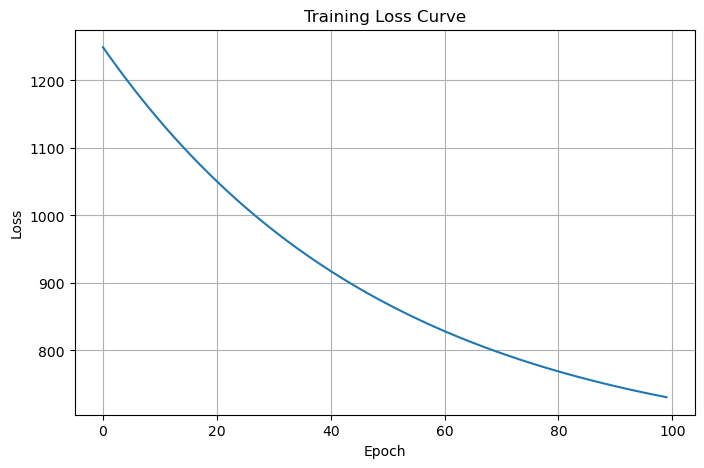

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Task 13 – Test the Trained Model

In [19]:
# New data
new_hours = np.array([[3],
                      [11],
                      [18]])

# Predict exam scores
_, _, _, predictions = forward(new_hours, W1, b1, W2, b2)

print("Predicted Exam Scores:\n")
for hour, score in zip(new_hours.flatten(), predictions.flatten()):
    print(f"Hours Studied: {hour} --> Predicted Score: {score:.2f}")

Predicted Exam Scores:

Hours Studied: 3 --> Predicted Score: 38.75
Hours Studied: 11 --> Predicted Score: 38.75
Hours Studied: 18 --> Predicted Score: 38.75


Task 14 – Bonus Challenge (Optional)

In [20]:
learning_rates = [0.01, 0.001, 0.0001]

print("Learning Rates Tested:")
for lr in learning_rates:
    print(lr)

Learning Rates Tested:
0.01
0.001
0.0001
